# Price forecasting with LSTMs: univariate, single-step and multi-step
**Problem:** Compare progressively richer recurrent models for forecasting a stock's close.
**Approach:** (1) a univariate LSTM against a mean baseline, (2) a multivariate (open/close/volume) single-step model, (3) a multi-step model that predicts the next 12 values. Windowing helpers produce the training datasets.
**Data:** Public Yahoo Finance history for `SDGR`.
**Attribution:** adapted from TensorFlow's official *Time series forecasting* tutorial (Apache-2.0), with the weather dataset replaced by stock prices. `TRAIN_SPLIT` is set to 80% of the available history, so it adapts to how long the ticker has traded.

In [1]:
import tensorflow as tf

import yfinance as yf

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [2]:
ticker = "SDGR"

In [3]:
stock = yf.Ticker(ticker)
df = stock.history(period="max")

In [4]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1670.000000,1670.000000,1670.000000,1670.000000,1.670000e+03,1670.0,1670.0
mean,35.445163,36.487514,34.385283,35.416877,9.750537e+05,0.0,0.0
std,21.296956,21.901057,20.605392,21.238646,7.949268e+05,0.0,0.0
min,11.150000,11.400000,10.945000,11.070000,1.569000e+05,0.0,0.0
25%,20.585000,21.110000,20.049999,20.580000,5.717750e+05,0.0,0.0
50%,26.700001,27.389999,25.884999,26.639999,7.872000e+05,0.0,0.0
75%,47.057500,49.067500,45.042500,47.117499,1.121275e+06,0.0,0.0
max,112.790001,117.000000,109.330002,113.089996,1.327110e+07,0.0,0.0


In [5]:
def univariate_data(dataset, start_index, end_index, history_size, target_size):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i)
    # Reshape data from (history_size,) to (history_size, 1)
    data.append(np.reshape(dataset[indices], (history_size, 1)))
    labels.append(dataset[i+target_size])
  return np.array(data), np.array(labels)

In [6]:
TRAIN_SPLIT = int(len(df) * 0.8)  # first 80% of days for training (the tutorial's fixed 2000 exceeds SDGR's history)
print('training rows:', TRAIN_SPLIT, 'of', len(df))

training rows: 1336 of 1670


In [7]:
tf.random.set_seed(13)

In [8]:
uni_data = df['Close']
uni_data.index = df.index
uni_data.head()

Date
2020-02-06 00:00:00-05:00    28.639999
2020-02-07 00:00:00-05:00    31.920000
2020-02-10 00:00:00-05:00    28.940001
2020-02-11 00:00:00-05:00    26.790001
2020-02-12 00:00:00-05:00    27.129999
Name: Close, dtype: float64

In [9]:
uni_data.plot(subplots=True, title=f'{ticker} daily close')

array([<Axes: xlabel='Date'>], dtype=object)

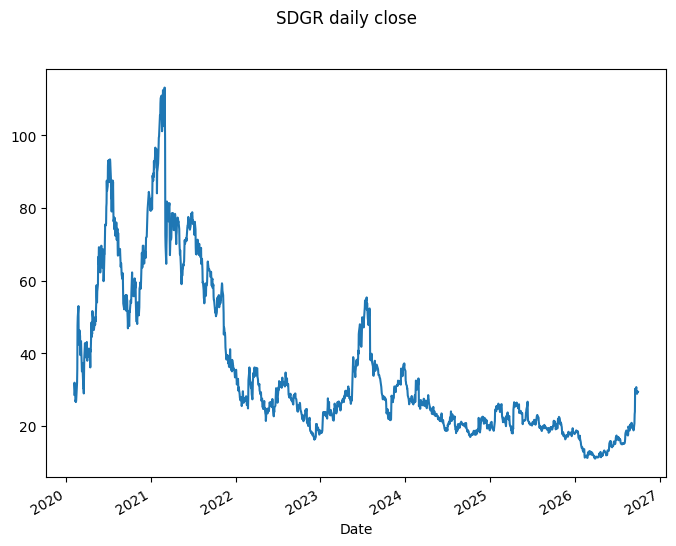

In [10]:
uni_data = uni_data.values

In [11]:
uni_train_mean = uni_data[:TRAIN_SPLIT].mean()
uni_train_std = uni_data[:TRAIN_SPLIT].std()

In [12]:
uni_data = (uni_data-uni_train_mean)/uni_train_std

In [13]:
univariate_past_history = 20
univariate_future_target = 0

x_train_uni, y_train_uni = univariate_data(uni_data, 0, TRAIN_SPLIT,
                                           univariate_past_history,
                                           univariate_future_target)
x_val_uni, y_val_uni = univariate_data(uni_data, TRAIN_SPLIT, None,
                                       univariate_past_history,
                                       univariate_future_target)

In [14]:
print ('Single window of past history')
print (x_train_uni[0])
print ('\n Target close (normalised) to predict')
print (y_train_uni[0])

Single window of past history
[[-0.52521183]
 [-0.37215039]
 [-0.51121226]
 [-0.61154213]
 [-0.59567609]
 [-0.62040851]
 [-0.60640903]
 [-0.37308371]
 [-0.19482309]
 [ 0.36049106]
 [ 0.47155396]
 [ 0.61108258]
 [ 0.17243091]
 [ 0.1164328 ]
 [ 0.16496451]
 [ 0.30262648]
 [ 0.22656238]
 [-0.01796263]
 [ 0.14489852]
 [ 0.05950136]]

 Target close (normalised) to predict
0.1598313224043357


In [15]:
def create_time_steps(length):
  return list(range(-length, 0))

In [16]:
def show_plot(plot_data, delta, title):
  labels = ['History', 'True Future', 'Model Prediction']
  marker = ['.-', 'rx', 'go']
  time_steps = create_time_steps(plot_data[0].shape[0])
  if delta:
    future = delta
  else:
    future = 0

  plt.title(title)
  for i, x in enumerate(plot_data):
    if i:
      plt.plot(future, plot_data[i], marker[i], markersize=10,
               label=labels[i])
    else:
      plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
  plt.legend()
  plt.xlim([time_steps[0], (future+5)*2])
  plt.xlabel('Time-Step')
  return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/site-packages/matplotlib/pyplot.py'>

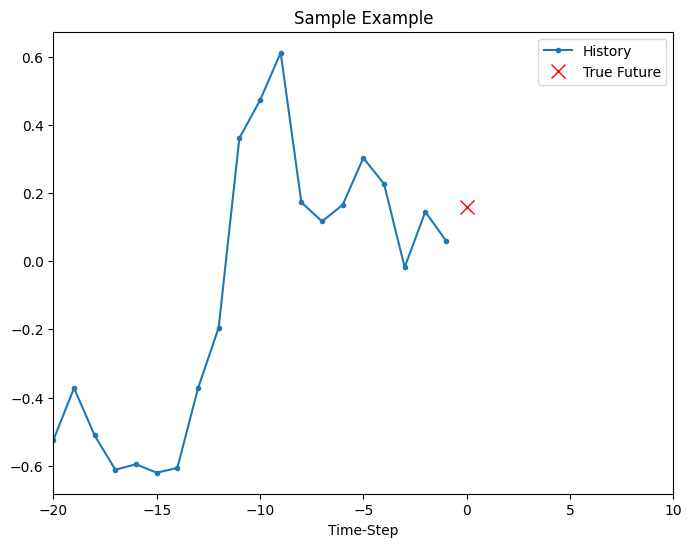

In [17]:
show_plot([x_train_uni[0], y_train_uni[0]], 0, 'Sample Example')

In [18]:
def baseline(history):
  return np.mean(history)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/site-packages/matplotlib/pyplot.py'>

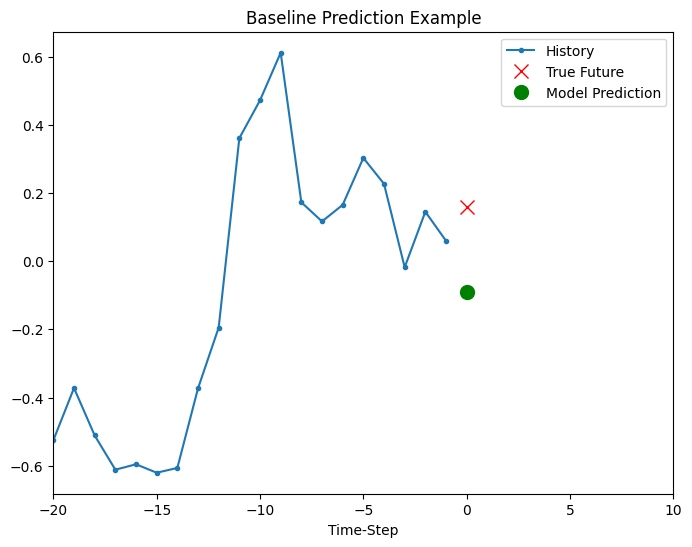

In [19]:
show_plot([x_train_uni[0], y_train_uni[0], baseline(x_train_uni[0])], 0,
           'Baseline Prediction Example')

In [20]:
BATCH_SIZE = 256
BUFFER_SIZE = 10000

train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni))
val_univariate = val_univariate.batch(BATCH_SIZE).repeat()

In [21]:
simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(8, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='adam', loss='mae')

In [22]:
for x, y in val_univariate.take(1):
    print(simple_lstm_model.predict(x).shape)

1/8 [==>...........................] - ETA: 2s

8/8 [==============================] - 0s 3ms/step


(256, 1)


In [23]:
EVALUATION_INTERVAL = 200
EPOCHS = 10

simple_lstm_model.fit(train_univariate, epochs=EPOCHS,
                      steps_per_epoch=EVALUATION_INTERVAL,
                      validation_data=val_univariate, validation_steps=50)

Epoch 1/10


  1/200 [..............................] - ETA: 6:56 - loss: 0.8615

  8/200 [>.............................] - ETA: 1s - loss: 0.8230  

 15/200 [=>............................] - ETA: 1s - loss: 0.7967

 23/200 [==>...........................] - ETA: 1s - loss: 0.7613

...

173/200 [========================>.....] - ETA: 0s - loss: 0.0618

181/200 [==========================>...] - ETA: 0s - loss: 0.0617

189/200 [===========================>..] - ETA: 0s - loss: 0.0617

196/200 [============================>.] - ETA: 0s - loss: 0.0617

200/200 [==============================] - 2s 8ms/step - loss: 0.0617 - val_loss: 0.0236


1/8 [==>...........................] - ETA: 0s

8/8 [==============================] - 0s 2ms/step


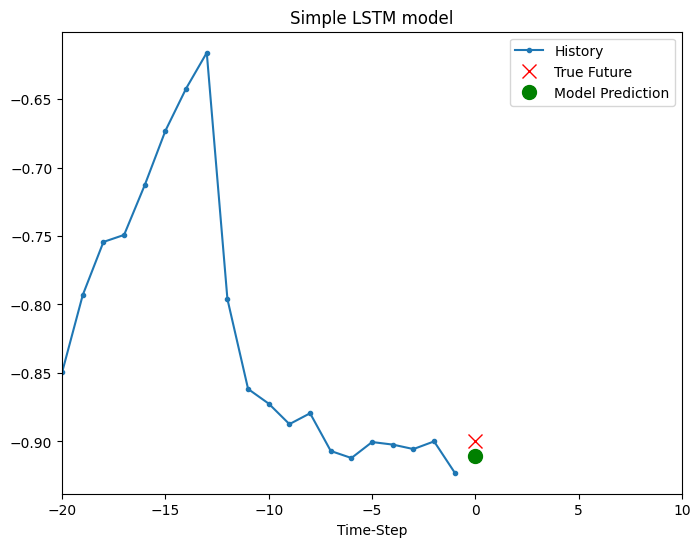

1/2 [==============>...............] - ETA: 0s

2/2 [==============================] - 0s 4ms/step


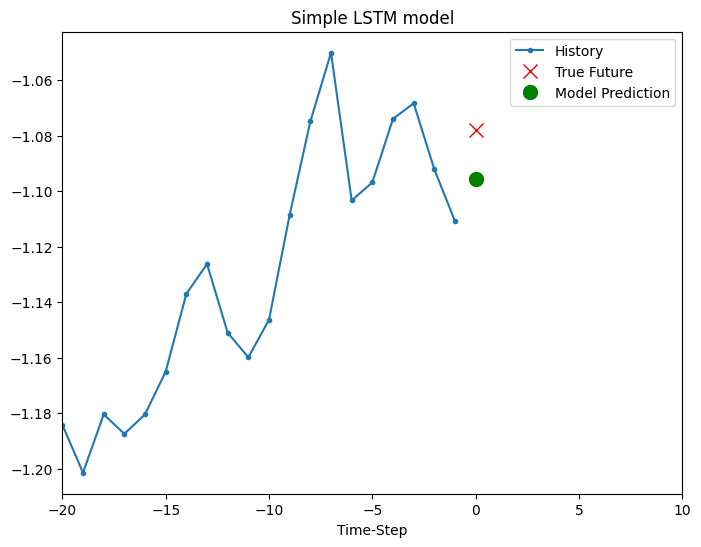

1/8 [==>...........................] - ETA: 0s

8/8 [==============================] - 0s 2ms/step


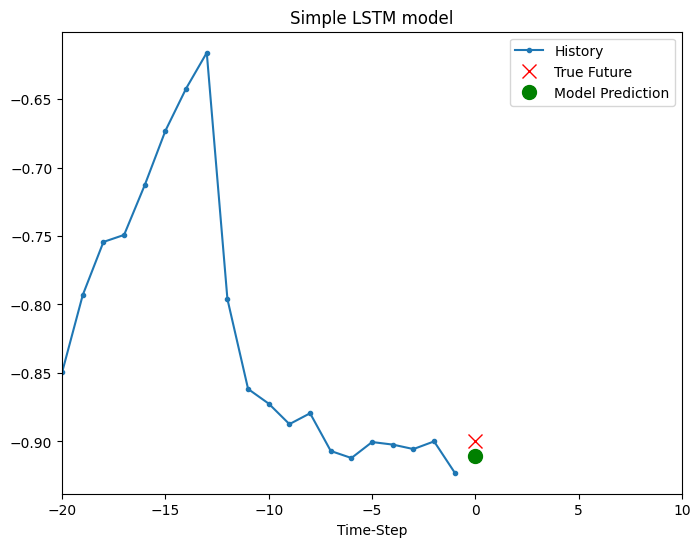

In [24]:
for x, y in val_univariate.take(3):
  plot = show_plot([x[0].numpy(), y[0].numpy(),
                    simple_lstm_model.predict(x)[0]], 0, 'Simple LSTM model')
  plot.show()

In [25]:
features_considered = ['Open', 'Close', 'Volume']

In [26]:
features = df[features_considered]
features.index = df.index
features.head()

,Open,Close,Volume
Date,,,
2020-02-06 00:00:00-05:00,26.000000,28.639999,7624500
2020-02-07 00:00:00-05:00,30.450001,31.920000,3225300
2020-02-10 00:00:00-05:00,32.380001,28.940001,2007500
2020-02-11 00:00:00-05:00,28.750000,26.790001,1253500
2020-02-12 00:00:00-05:00,27.330000,27.129999,1510600


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

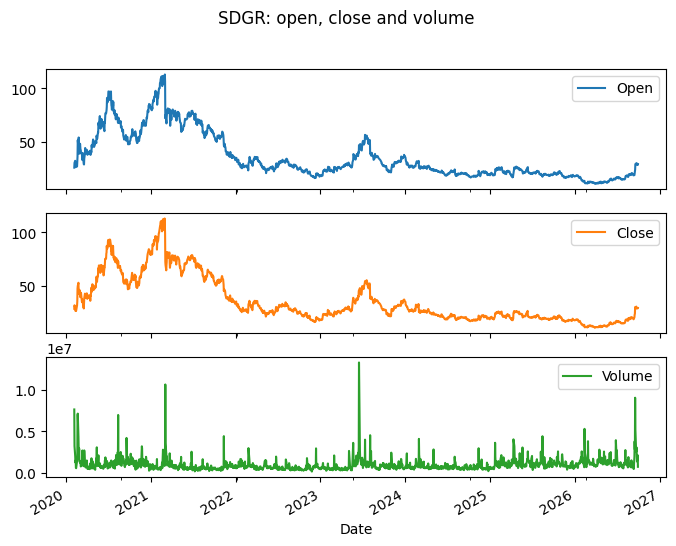

In [27]:
features.plot(subplots=True, title=f'{ticker}: open, close and volume')

In [28]:
dataset = features.values
data_mean = dataset[:TRAIN_SPLIT].mean(axis=0)
data_std = dataset[:TRAIN_SPLIT].std(axis=0)

In [29]:
dataset = (dataset-data_mean)/data_std

In [30]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [31]:
past_history = 120
future_target = 12
STEP = 1

x_train_single, y_train_single = multivariate_data(dataset, dataset[:, 1], 0,
                                                   TRAIN_SPLIT, past_history,
                                                   future_target, STEP,
                                                   single_step=True)
x_val_single, y_val_single = multivariate_data(dataset, dataset[:, 1],
                                               TRAIN_SPLIT, None, past_history,
                                               future_target, STEP,
                                               single_step=True)

In [32]:
print ('Single window of past history : {}'.format(x_train_single[0].shape))

Single window of past history : (120, 3)


In [33]:
train_data_single = tf.data.Dataset.from_tensor_slices((x_train_single, y_train_single))
train_data_single = train_data_single.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_single = tf.data.Dataset.from_tensor_slices((x_val_single, y_val_single))
val_data_single = val_data_single.batch(BATCH_SIZE).repeat()

In [34]:
single_step_model = tf.keras.models.Sequential()
single_step_model.add(tf.keras.layers.LSTM(32,
                                           input_shape=x_train_single.shape[-2:]))
single_step_model.add(tf.keras.layers.Dense(1))

single_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(), loss='mae')

In [35]:
for x, y in val_data_single.take(1):
  print(single_step_model.predict(x).shape)

1/7 [===>..........................] - ETA: 2s

7/7 [==============================] - 0s 8ms/step


(202, 1)


In [36]:
single_step_history = single_step_model.fit(train_data_single, epochs=EPOCHS,
                                            steps_per_epoch=EVALUATION_INTERVAL,
                                            validation_data=val_data_single,
                                            validation_steps=50)

Epoch 1/10


  1/200 [..............................] - ETA: 5:20 - loss: 0.7058

  2/200 [..............................] - ETA: 12s - loss: 0.6872 

  3/200 [..............................] - ETA: 11s - loss: 0.6400

  4/200 [..............................] - ETA: 11s - loss: 0.6198

...

196/200 [============================>.] - ETA: 0s - loss: 0.0666

197/200 [============================>.] - ETA: 0s - loss: 0.0666

198/200 [============================>.] - ETA: 0s - loss: 0.0666

199/200 [============================>.] - ETA: 0s - loss: 0.0666

200/200 [==============================] - 12s 58ms/step - loss: 0.0666 - val_loss: 0.2739


In [37]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

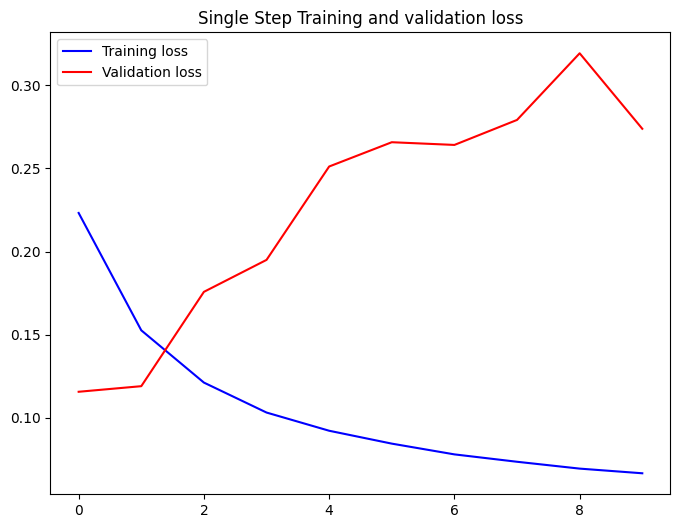

In [38]:
plot_train_history(single_step_history,
                   'Single Step Training and validation loss')

1/7 [===>..........................] - ETA: 0s

7/7 [==============================] - 0s 7ms/step


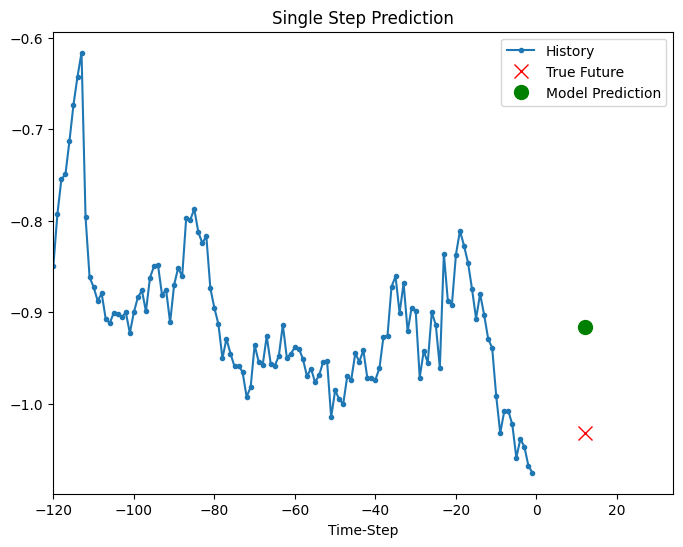

1/7 [===>..........................] - ETA: 0s

7/7 [==============================] - 0s 7ms/step


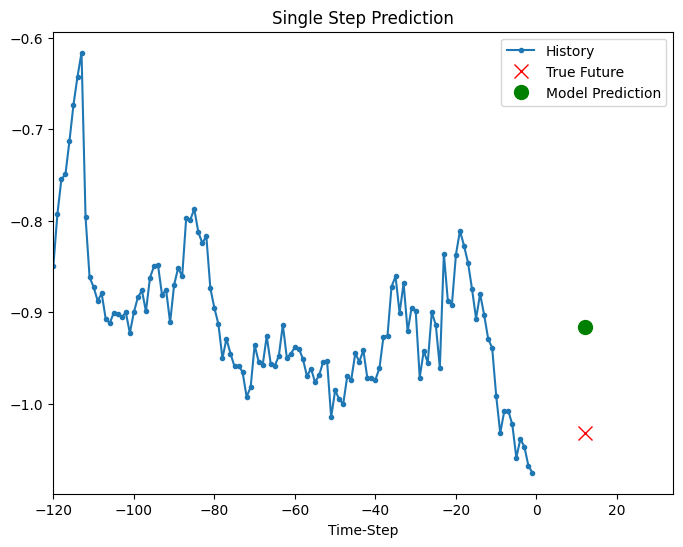

1/7 [===>..........................] - ETA: 0s

7/7 [==============================] - 0s 8ms/step


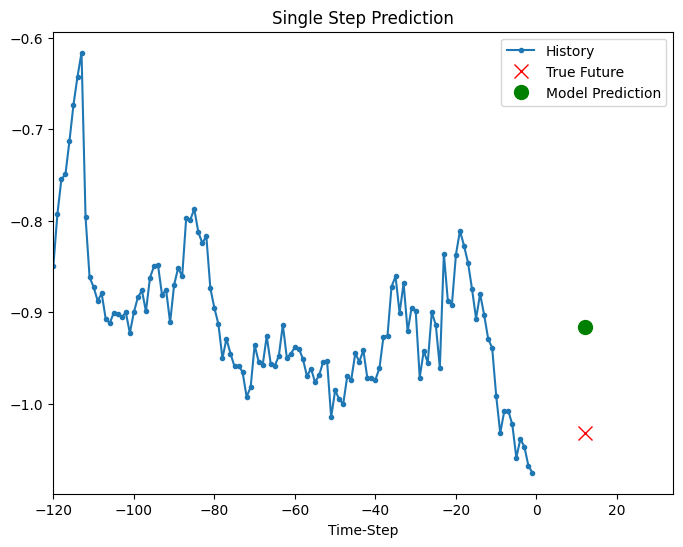

In [39]:
for x, y in val_data_single.take(3):
  plot = show_plot([x[0][:, 1].numpy(), y[0].numpy(),
                    single_step_model.predict(x)[0]], 12,
                   'Single Step Prediction')
  plot.show()

In [40]:
future_target = 12
x_train_multi, y_train_multi = multivariate_data(dataset, dataset[:, 1], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_multi, y_val_multi = multivariate_data(dataset, dataset[:, 1],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [41]:
print ('Single window of past history : {}'.format(x_train_multi[0].shape))
print ('\n Target Close price to predict : {}'.format(y_train_multi[0].shape))

Single window of past history : (120, 3)

 Target Close price to predict : (12,)


In [42]:
train_data_multi = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
train_data_multi = train_data_multi.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_multi = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
val_data_multi = val_data_multi.batch(BATCH_SIZE).repeat()

In [43]:
def multi_step_plot(history, true_future, prediction):
  plt.figure(figsize=(12, 6))
  num_in = create_time_steps(len(history))
  num_out = len(true_future)

  plt.plot(num_in, np.array(history[:, 1]), label='History')
  plt.plot(np.arange(num_out)/STEP, np.array(true_future), 'bo',
           label='True Future')
  if prediction.any():
    plt.plot(np.arange(num_out)/STEP, np.array(prediction), 'ro',
             label='Predicted Future')
  plt.title('Multi-step forecast: next 12 days')
  plt.xlabel('Time-step')
  plt.ylabel('Close (normalised)')
  plt.legend(loc='upper left')
  plt.show()

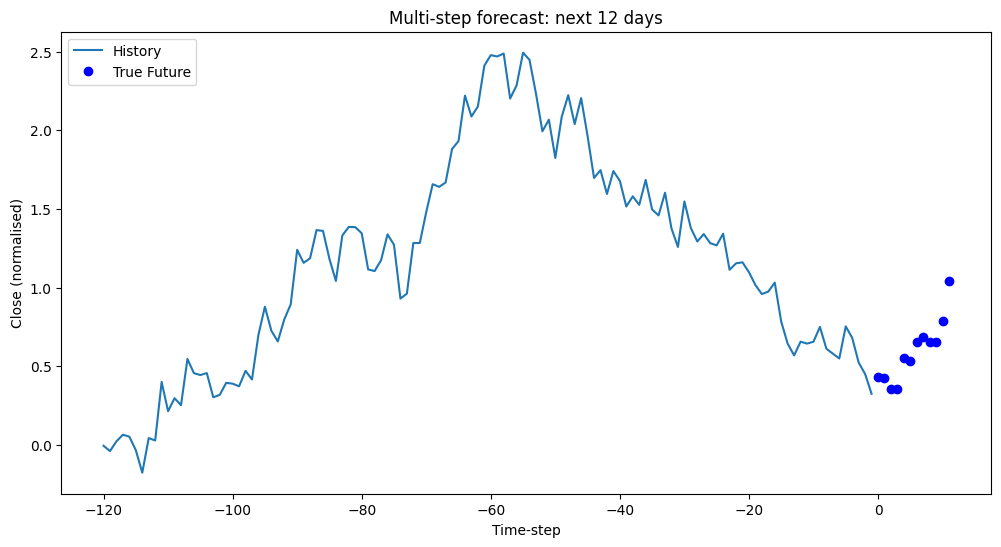

In [44]:
for x, y in train_data_multi.take(1):
  multi_step_plot(x[0], y[0], np.array([0]))

In [45]:
multi_step_model = tf.keras.models.Sequential()
multi_step_model.add(tf.keras.layers.LSTM(32,
                                          return_sequences=True,
                                          input_shape=x_train_multi.shape[-2:]))
multi_step_model.add(tf.keras.layers.LSTM(16, activation='relu'))
multi_step_model.add(tf.keras.layers.Dense(12))

multi_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(clipvalue=1.0), loss='mae')

In [46]:
for x, y in val_data_multi.take(1):
  print (multi_step_model.predict(x).shape)

1/7 [===>..........................] - ETA: 2s

5/7 [====================>.........] - ETA: 0s

7/7 [==============================] - 1s 15ms/step


(202, 12)


In [47]:
multi_step_history = multi_step_model.fit(train_data_multi, epochs=EPOCHS,
                                          steps_per_epoch=EVALUATION_INTERVAL,
                                          validation_data=val_data_multi,
                                          validation_steps=50)

Epoch 1/10


  1/200 [..............................] - ETA: 8:07 - loss: 0.8723

  2/200 [..............................] - ETA: 18s - loss: 0.8326 

  3/200 [..............................] - ETA: 18s - loss: 0.8242

  4/200 [..............................] - ETA: 18s - loss: 0.8176

...

197/200 [============================>.] - ETA: 0s - loss: 0.0834

198/200 [============================>.] - ETA: 0s - loss: 0.0835

199/200 [============================>.] - ETA: 0s - loss: 0.0835

200/200 [==============================] - ETA: 0s - loss: 0.0835

200/200 [==============================] - 22s 109ms/step - loss: 0.0835 - val_loss: 0.2591


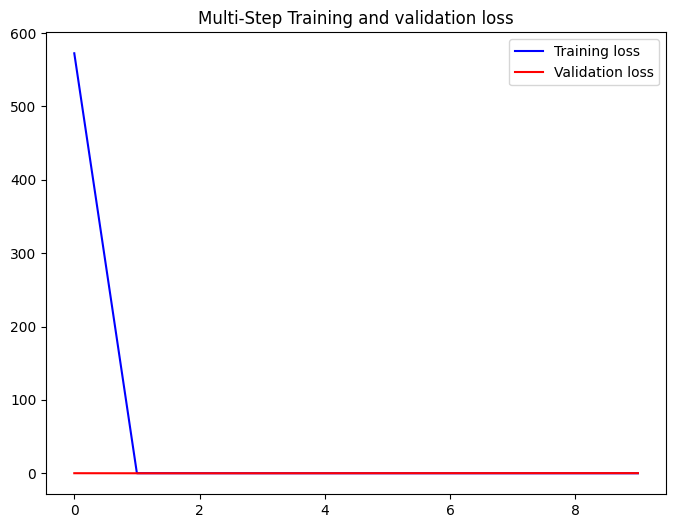

In [48]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

1/7 [===>..........................] - ETA: 0s

5/7 [====================>.........] - ETA: 0s

7/7 [==============================] - 0s 13ms/step


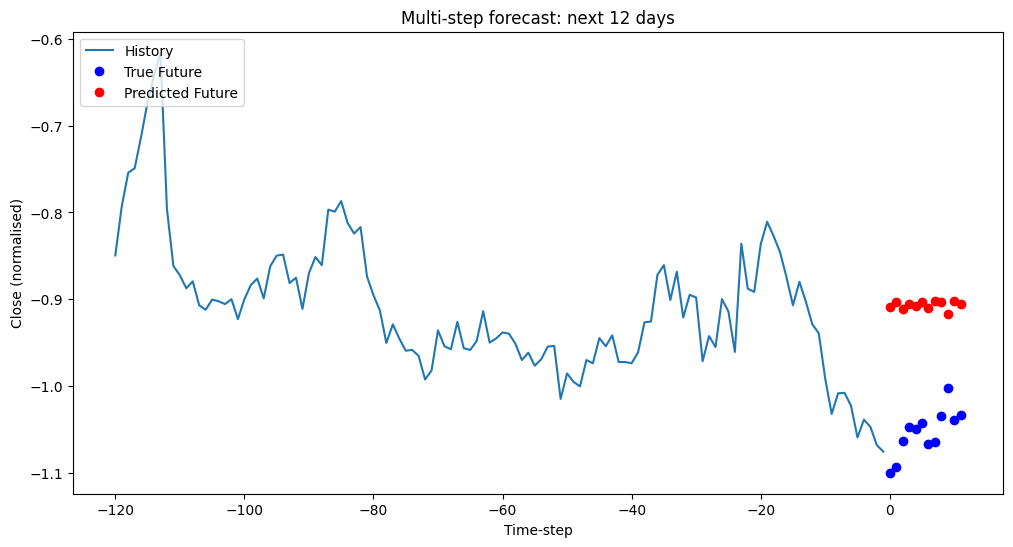

1/7 [===>..........................] - ETA: 0s

5/7 [====================>.........] - ETA: 0s

7/7 [==============================] - 0s 13ms/step


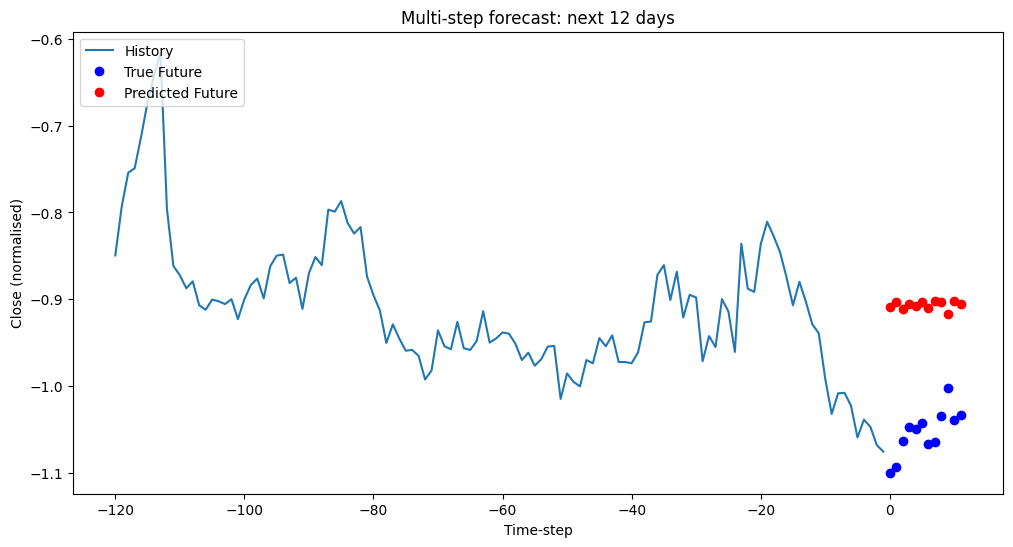

1/7 [===>..........................] - ETA: 0s

5/7 [====================>.........] - ETA: 0s

7/7 [==============================] - 0s 13ms/step


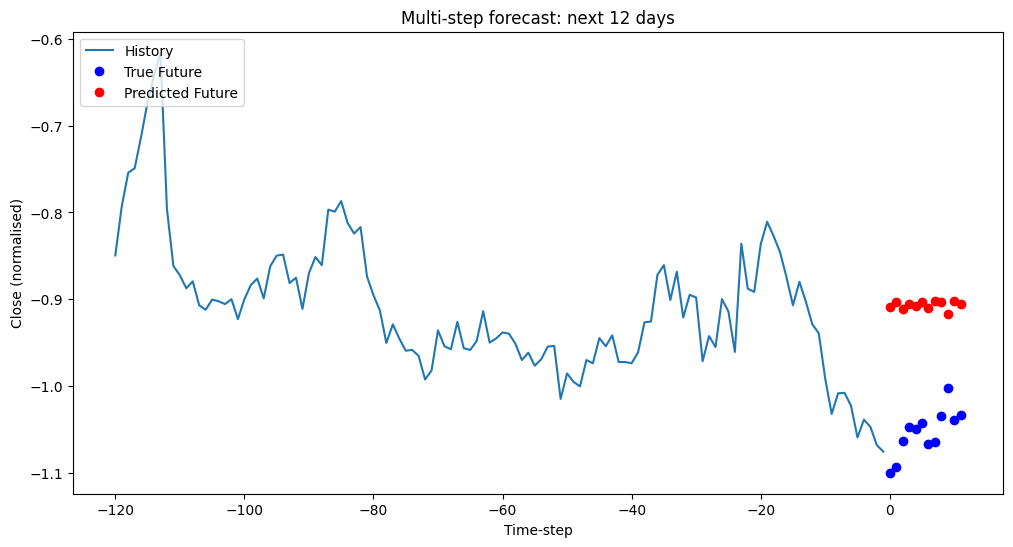

In [49]:
for x, y in val_data_multi.take(3):
  multi_step_plot(x[0], y[0], multi_step_model.predict(x)[0])